In [13]:
from coffea.util import load
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

## Load coffea files

In [14]:
input_main = "/work/mmalucch/out_hh4b/test_main/output_VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE.coffea"
input_test = "/work/mmalucch/out_hh4b/test/output_VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE.coffea"

o_main = load(input_main)
o_test = load(input_test)

print("test_main keys:", list(o_main.keys()))
print("test      keys:", list(o_test.keys()))

test_main keys: ['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata']
test      keys: ['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata']


## Explore structure

In [15]:
def print_structure(o, label):
    print(f"=== {label} ===")
    for sample in o["columns"]:
        print(f"  sample: {sample}")
        for dataset in o["columns"][sample]:
            print(f"    dataset: {dataset}")
            for cat in o["columns"][sample][dataset]:
                keys = list(o["columns"][sample][dataset][cat].keys())
                print(f"      category: {cat}  ({len(keys)} arrays)")
                print(f"        arrays: {keys[:8]}{'...' if len(keys) > 8 else ''}")

print_structure(o_main, "test_main")
print()
print_structure(o_test, "test")

=== test_main ===
  sample: VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4
    dataset: VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE
      category: 4b_region  (1 arrays)
        arrays: ['nominal']

=== test ===
  sample: VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4
    dataset: VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE
      category: hh4b_vbf_best_candidates_6_jets_nokincut_region  (1 arrays)
        arrays: ['nominal']
      category: hh4b_vbf_best_candidates_6_jets_region  (1 arrays)
        arrays: ['nominal']
      category: 4b_region  (1 arrays)
        arrays: ['nominal']


## Extract columns (first sample/dataset found)

In [16]:
def get_columns(o):
    sample  = list(o["columns"].keys())[0]
    dataset = list(o["columns"][sample].keys())[0]
    return o["columns"][sample][dataset]

cols_main = get_columns(o_main)
cols_test = get_columns(o_test)

print("categories in test_main:", list(cols_main.keys()))
print("categories in test:     ", list(cols_test.keys()))

categories in test_main: ['4b_region']
categories in test:      ['hh4b_vbf_best_candidates_6_jets_nokincut_region', 'hh4b_vbf_best_candidates_6_jets_region', '4b_region']


## Compare array sizes across all categories

In [17]:
for cat in cols_main:
    if cat not in cols_test:
        print(f"[MISSING in test] category: {cat}")
        continue
    print(f"\n--- category: {cat} ---")
    cols_arrays      = cols_main[cat]['nominal']
    cols_arrays_test = cols_test[cat]['nominal']
    for col in cols_arrays:
        v_main = cols_arrays[col].value
        entry_test = cols_arrays_test.get(col)
        if entry_test is None:
            print(f"  [MISSING in test] {col}")
            continue
        v_test = entry_test.value
        match = "OK" if len(v_main) == len(v_test) else "SIZE MISMATCH"
        print(f"  {col:<50s}  main={len(v_main):>8d}  test={len(v_test):>8d}  {match}")


--- category: 4b_region ---
  weight                                              main=    2726  test=    2726  OK
  JetTotalSPANetPadded_N                              main=    2726  test=    2726  OK
  JetTotalSPANetPadded_provenance                     main=   24534  test=   24534  OK
  JetTotalSPANetPadded_provenance_higgs               main=   24534  test=   24534  OK
  JetTotalSPANetPadded_provenance_vbf                 main=   24534  test=   24534  OK
  JetTotalSPANetPadded_pt                             main=   24534  test=   24534  OK
  JetTotalSPANetPadded_eta                            main=   24534  test=   24534  OK
  JetTotalSPANetPadded_phi                            main=   24534  test=   24534  OK
  JetTotalSPANetPadded_mass                           main=   24534  test=   24534  OK
  JetTotalSPANetPadded_btagPNetB_5wp                  main=   24534  test=   24534  OK
  JetTotalSPANetPadded_btagPNetB_3wp                  main=   24534  test=   24534  OK
  JetTotalSPAN

## Value-by-value comparison for a chosen category

In [18]:
# Change CATEGORY to whichever category you want
CATEGORY = list(cols_main.keys())[0]
print("comparing category:", CATEGORY)

cat_main = cols_main[CATEGORY]['nominal']
cat_test = cols_test[CATEGORY]['nominal']

diffs = {}
for col in cat_main:
    if col not in cat_test:
        print(f"  [MISSING in test] {col}")
        continue
    v1 = cat_main[col].value
    v2 = cat_test[col].value
    if len(v1) != len(v2):
        print(f"  SIZE MISMATCH  {col}  ({len(v1)} vs {len(v2)})")
        continue
    n_diff = int(np.sum(v1 != v2))
    if n_diff > 0:
        diffs[col] = (v1, v2, n_diff)
        print(f"  DIFF  {col:<50s}  n_diff={n_diff}/{len(v1)}")
    else:
        print(f"  equal {col}")

comparing category: 4b_region
  equal weight
  equal JetTotalSPANetPadded_N
  equal JetTotalSPANetPadded_provenance
  equal JetTotalSPANetPadded_provenance_higgs
  equal JetTotalSPANetPadded_provenance_vbf
  equal JetTotalSPANetPadded_pt
  equal JetTotalSPANetPadded_eta
  equal JetTotalSPANetPadded_phi
  equal JetTotalSPANetPadded_mass
  equal JetTotalSPANetPadded_btagPNetB_5wp
  equal JetTotalSPANetPadded_btagPNetB_3wp
  equal JetTotalSPANetPadded_btagPNetB
  equal JetTotalSPANetPtFlattenPadded_N
  equal JetTotalSPANetPtFlattenPadded_provenance
  equal JetTotalSPANetPtFlattenPadded_provenance_higgs
  equal JetTotalSPANetPtFlattenPadded_provenance_vbf
  DIFF  JetTotalSPANetPtFlattenPadded_pt                    n_diff=6659/24534
  equal JetTotalSPANetPtFlattenPadded_eta
  equal JetTotalSPANetPtFlattenPadded_phi
  DIFF  JetTotalSPANetPtFlattenPadded_mass                  n_diff=6659/24534
  equal JetTotalSPANetPtFlattenPadded_btagPNetB_5wp
  equal JetTotalSPANetPtFlattenPadded_btagPNetB_

## Plot distributions for columns that differ

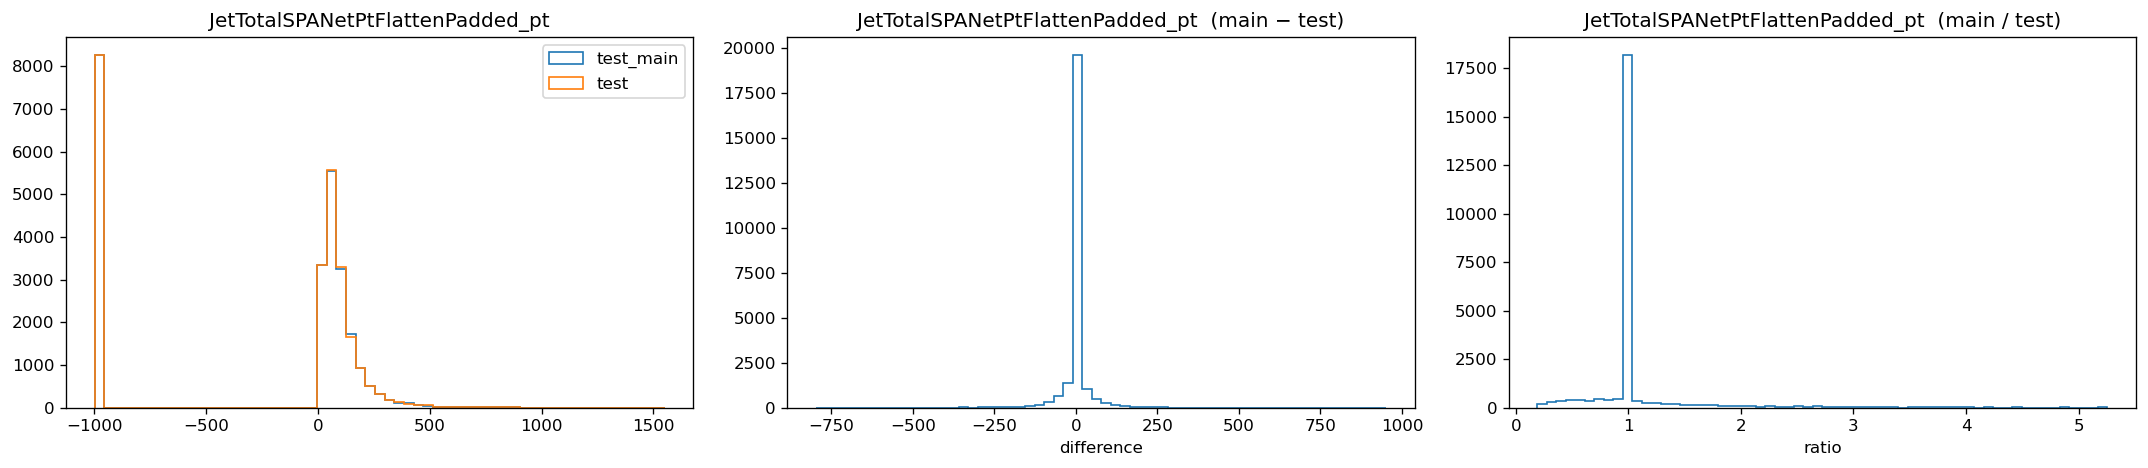

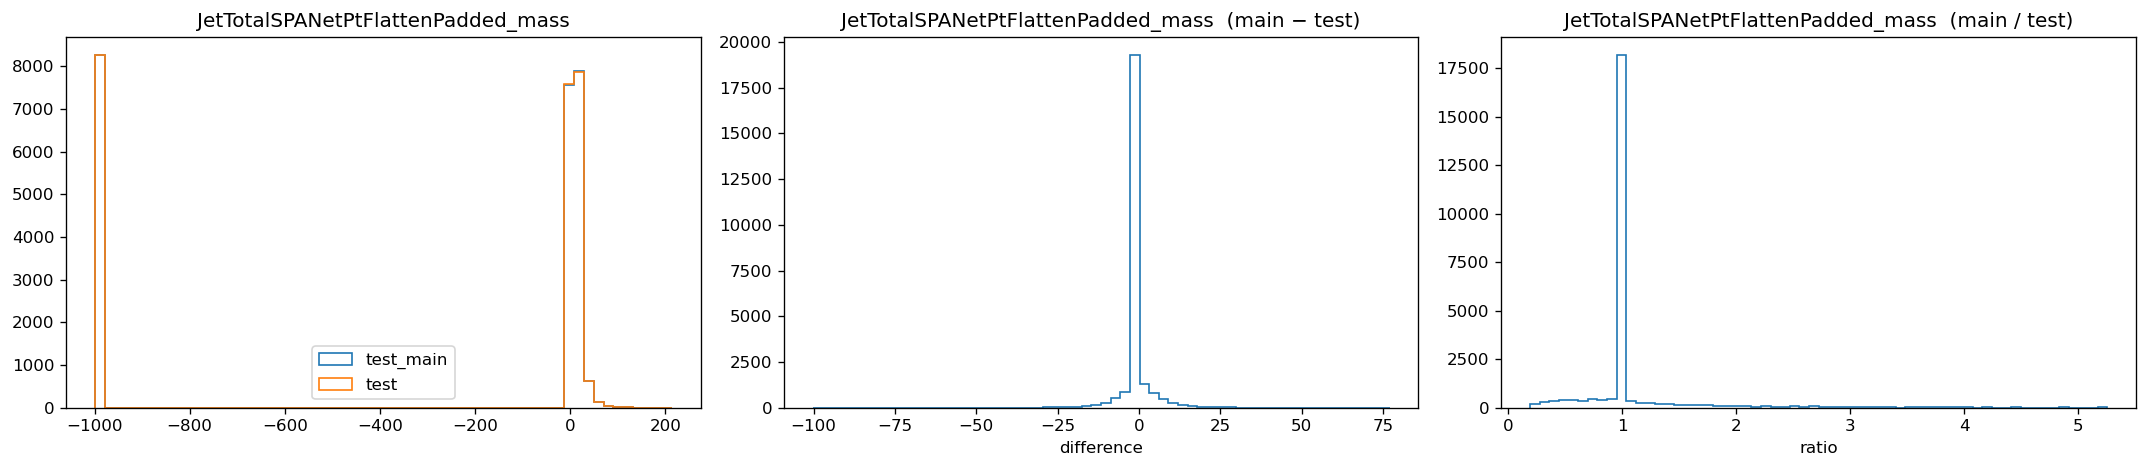

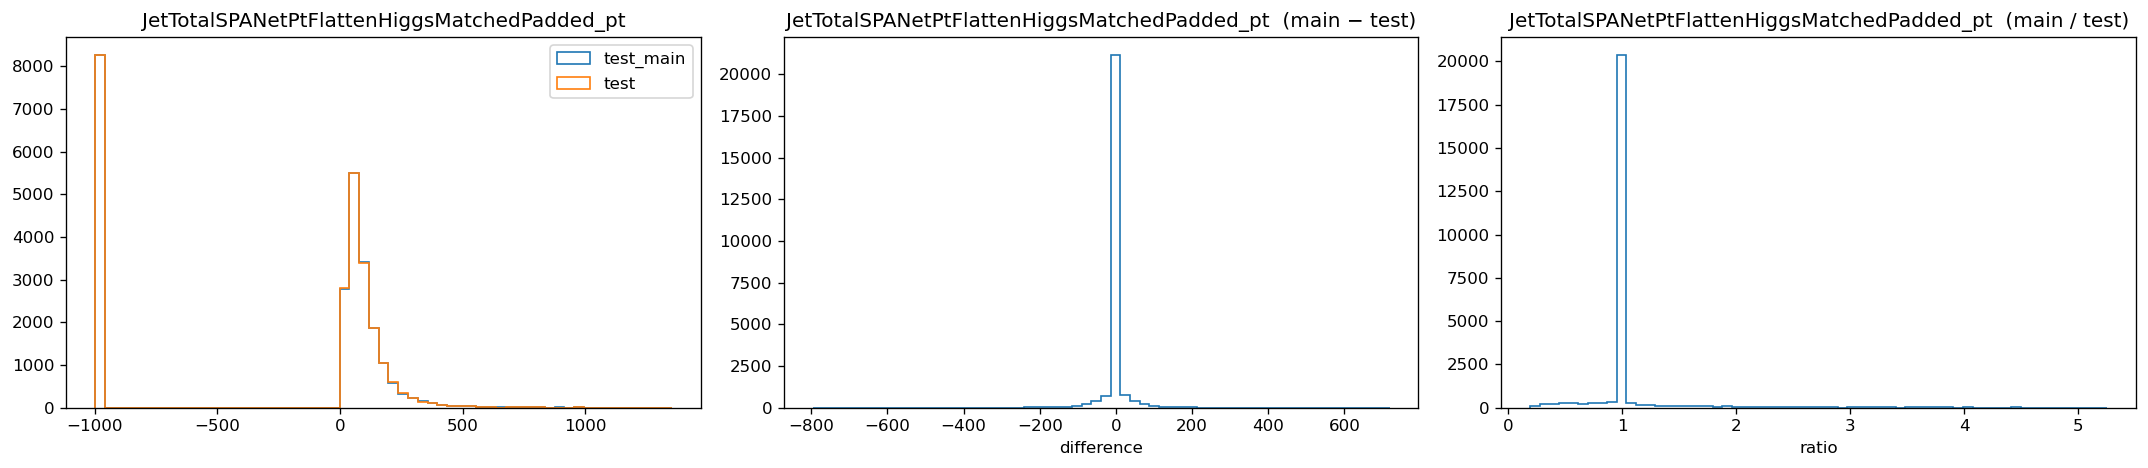

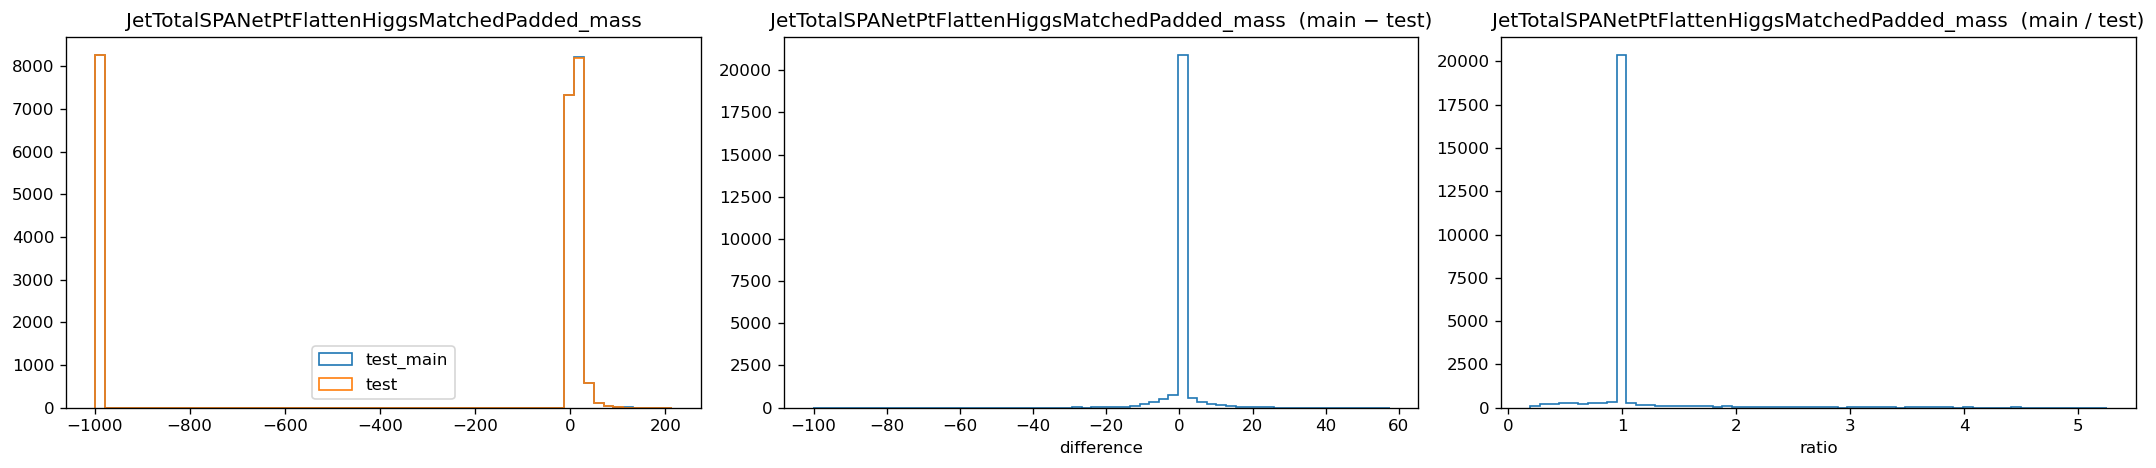

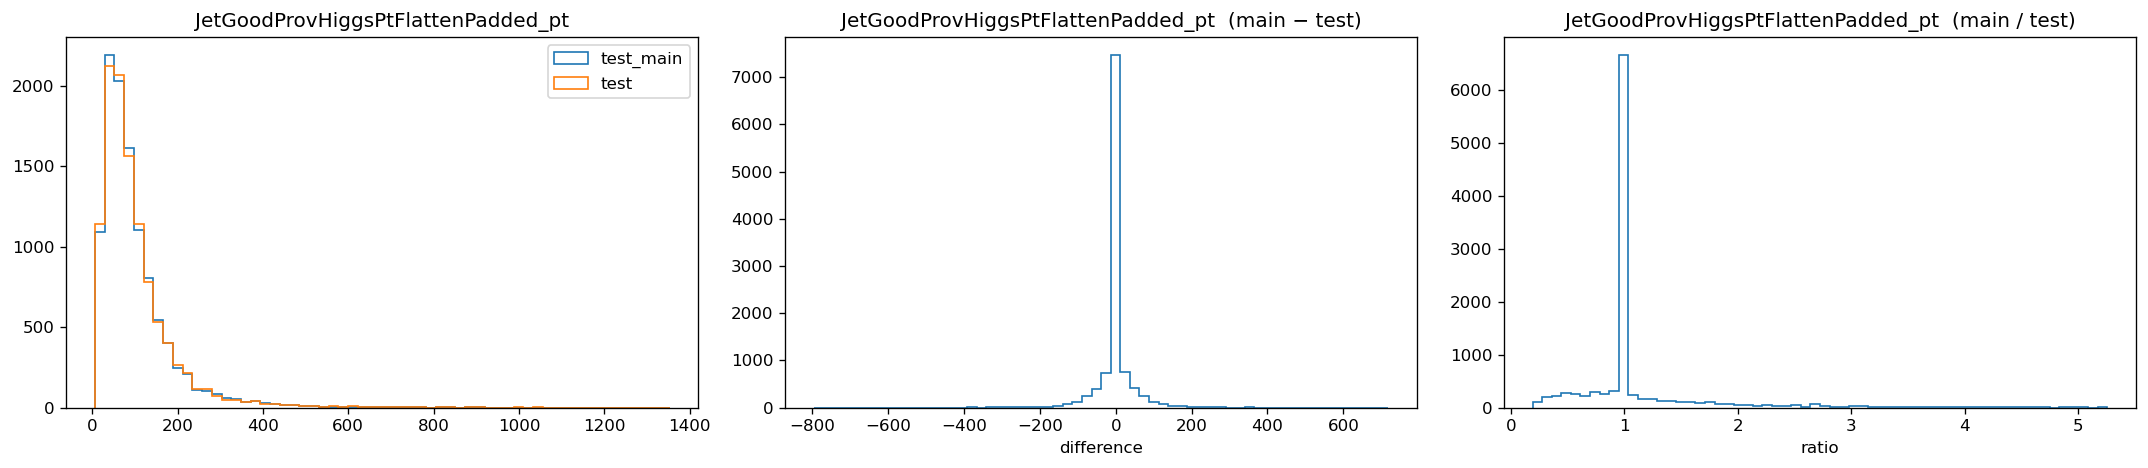

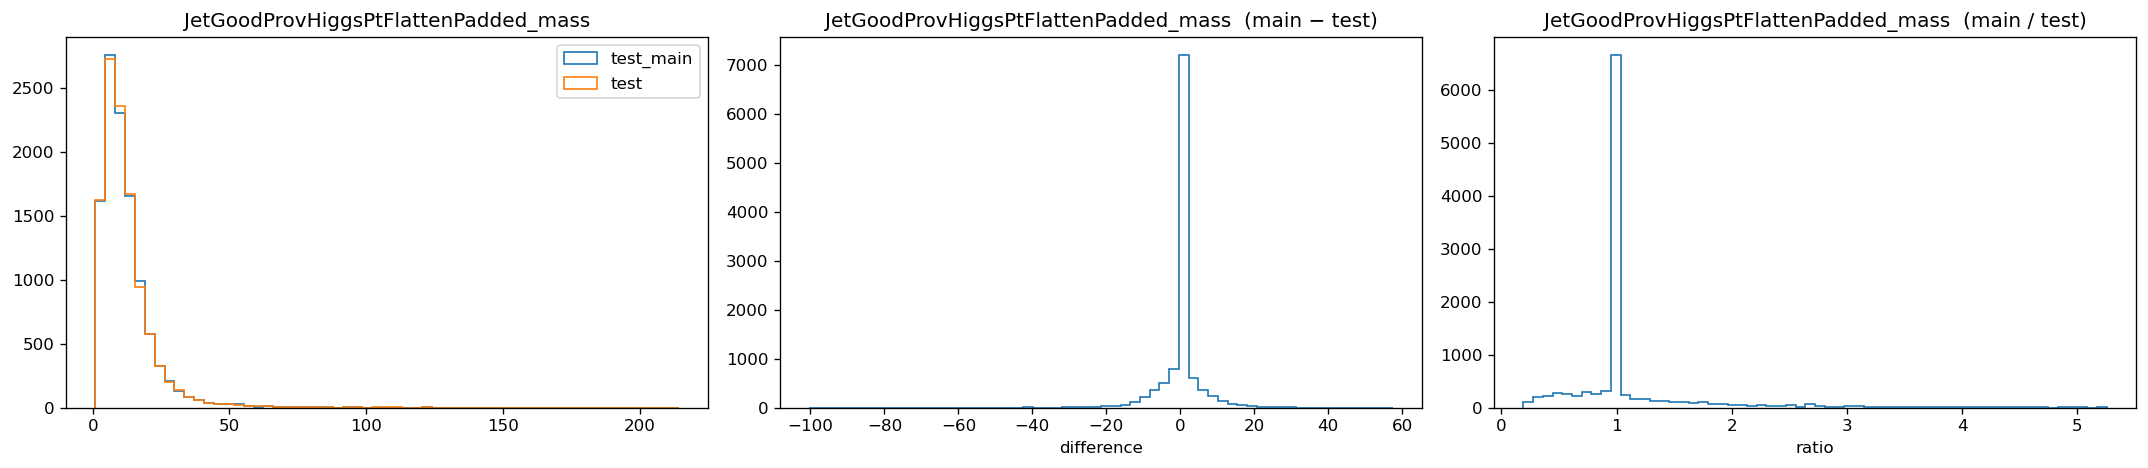

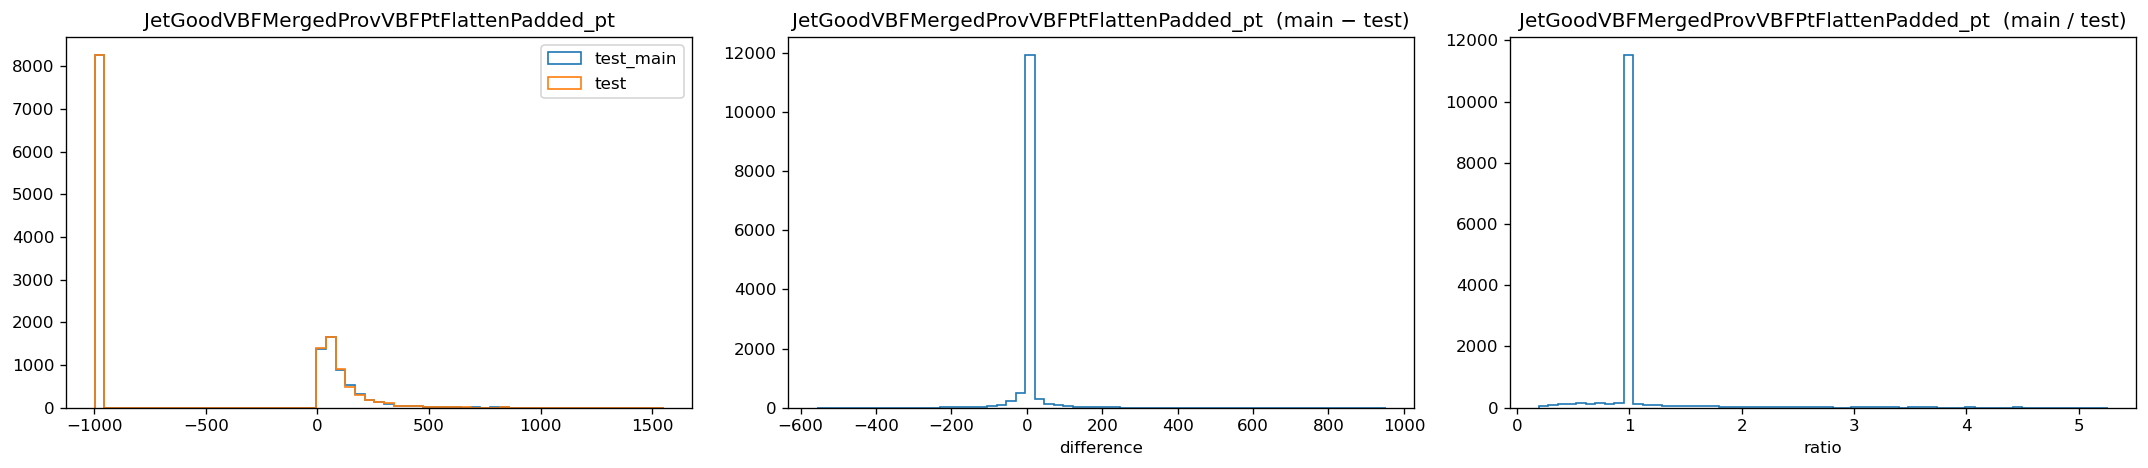

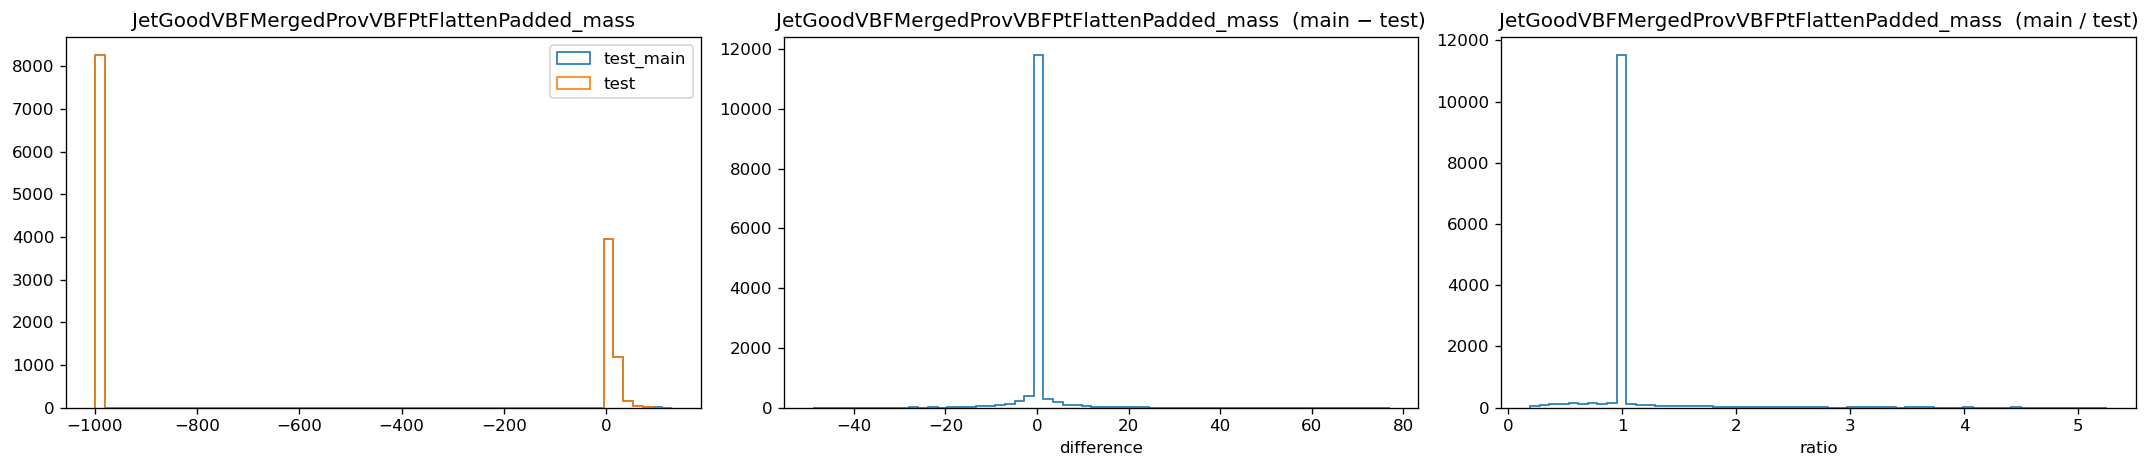

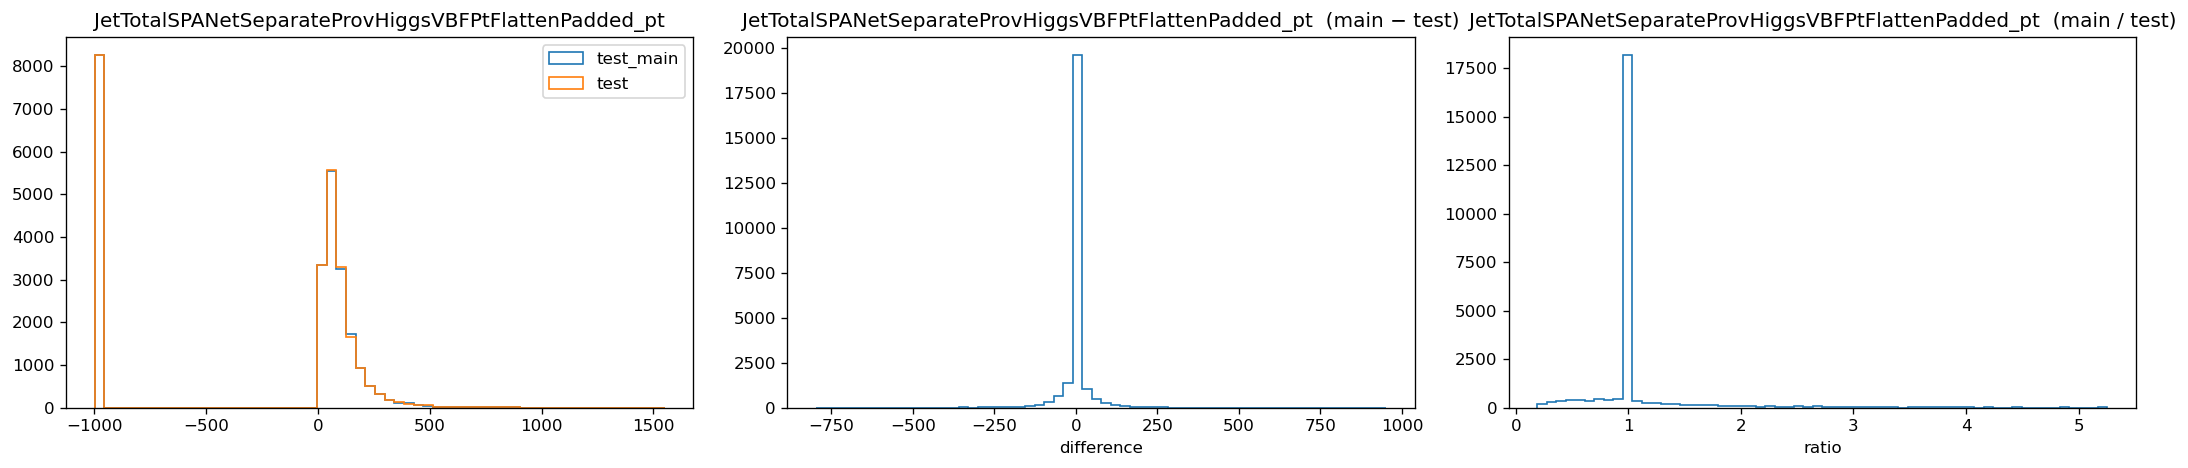

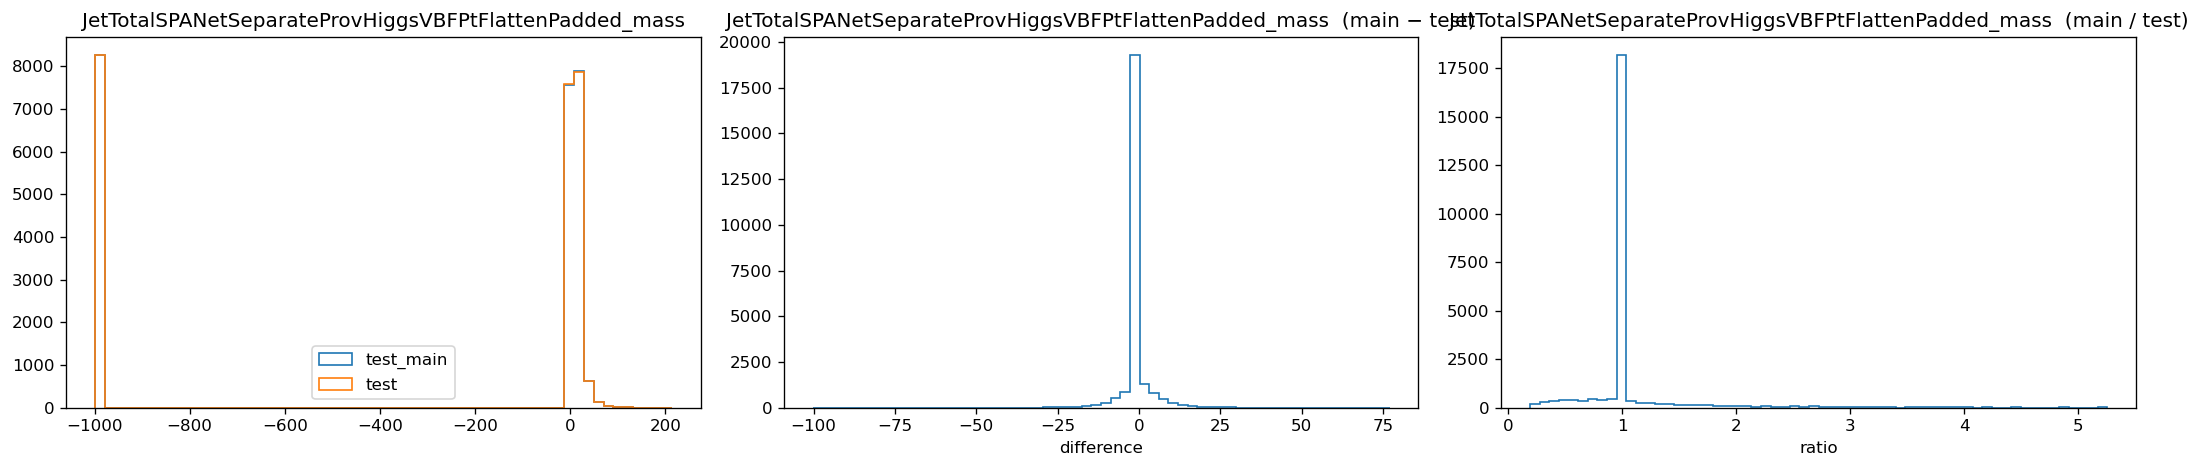

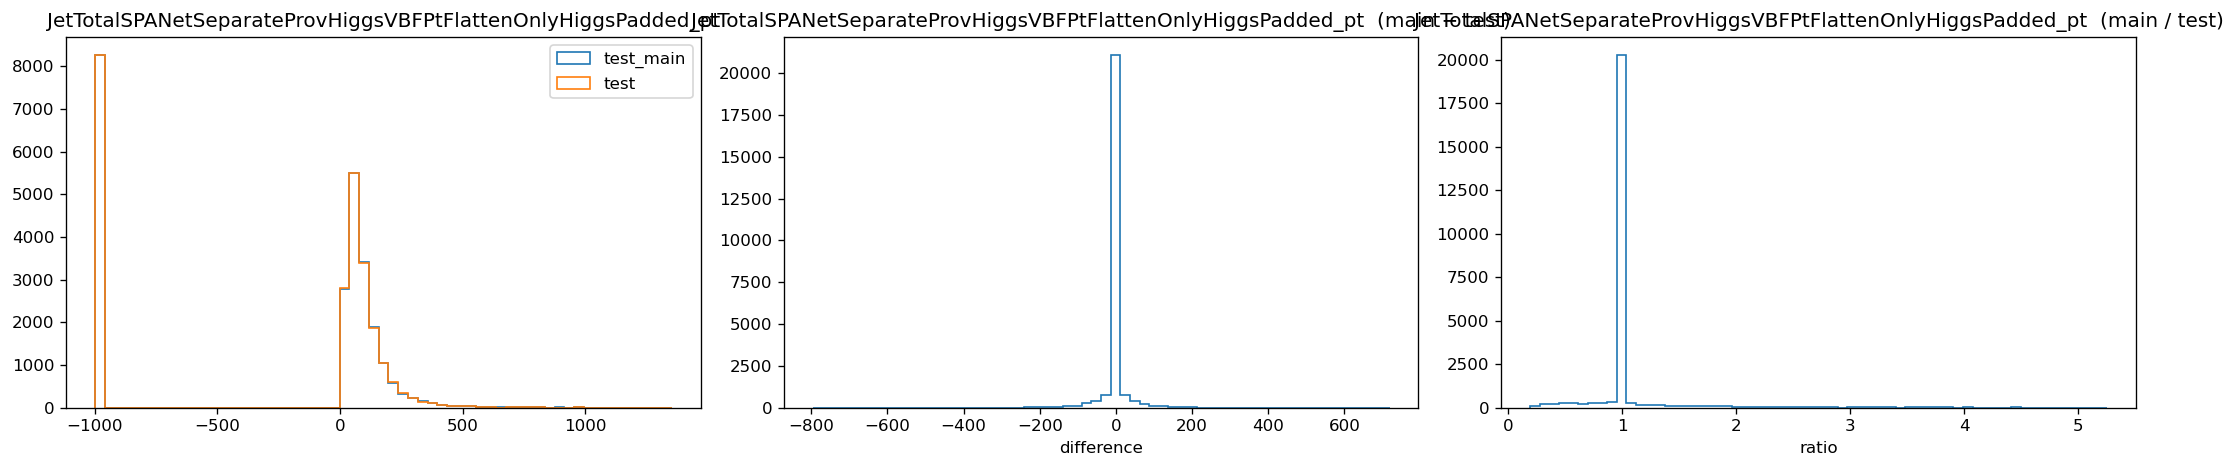

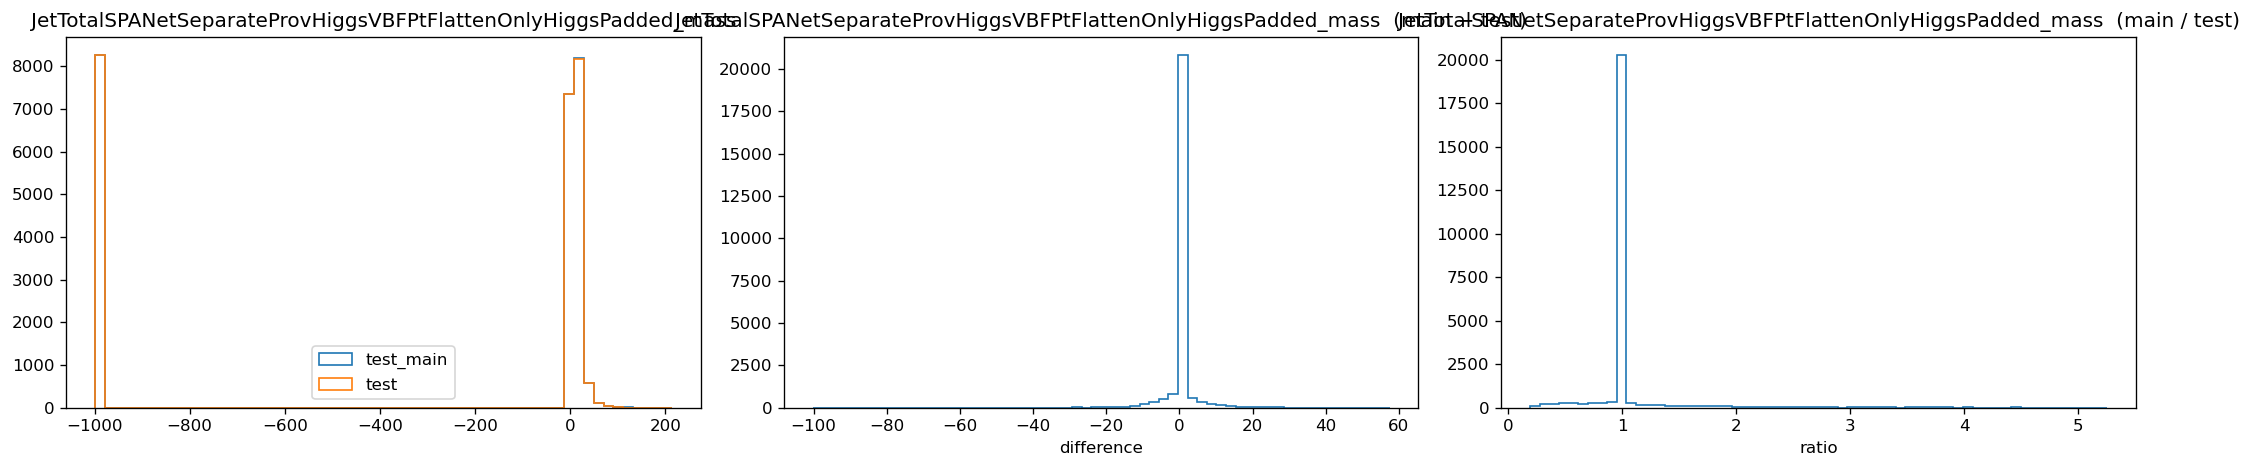

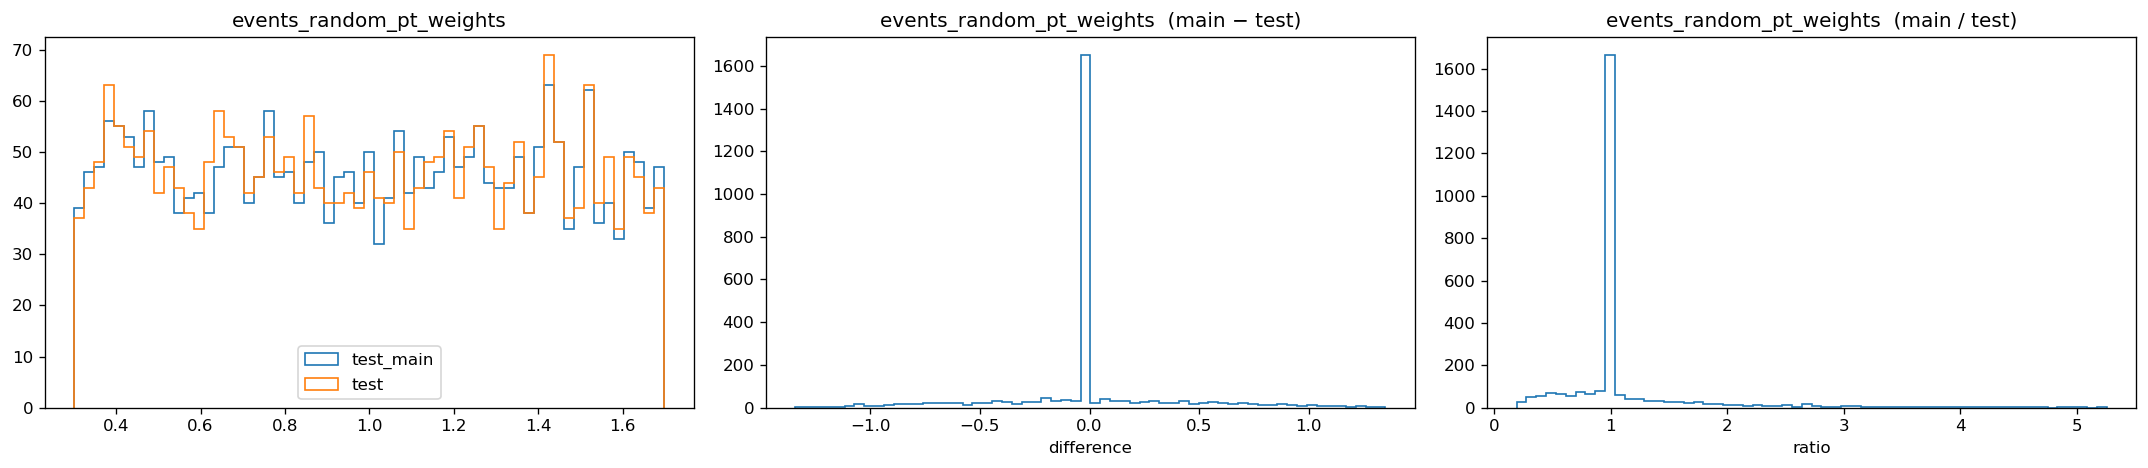

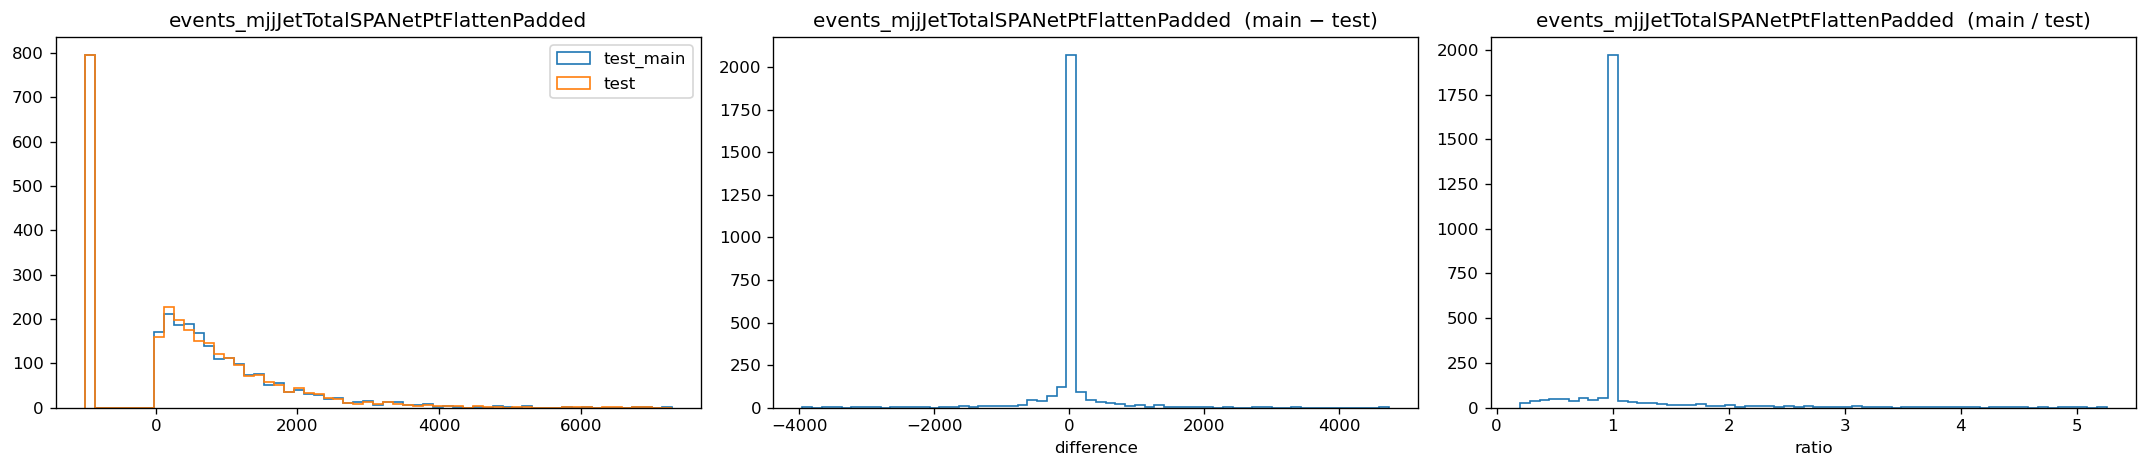

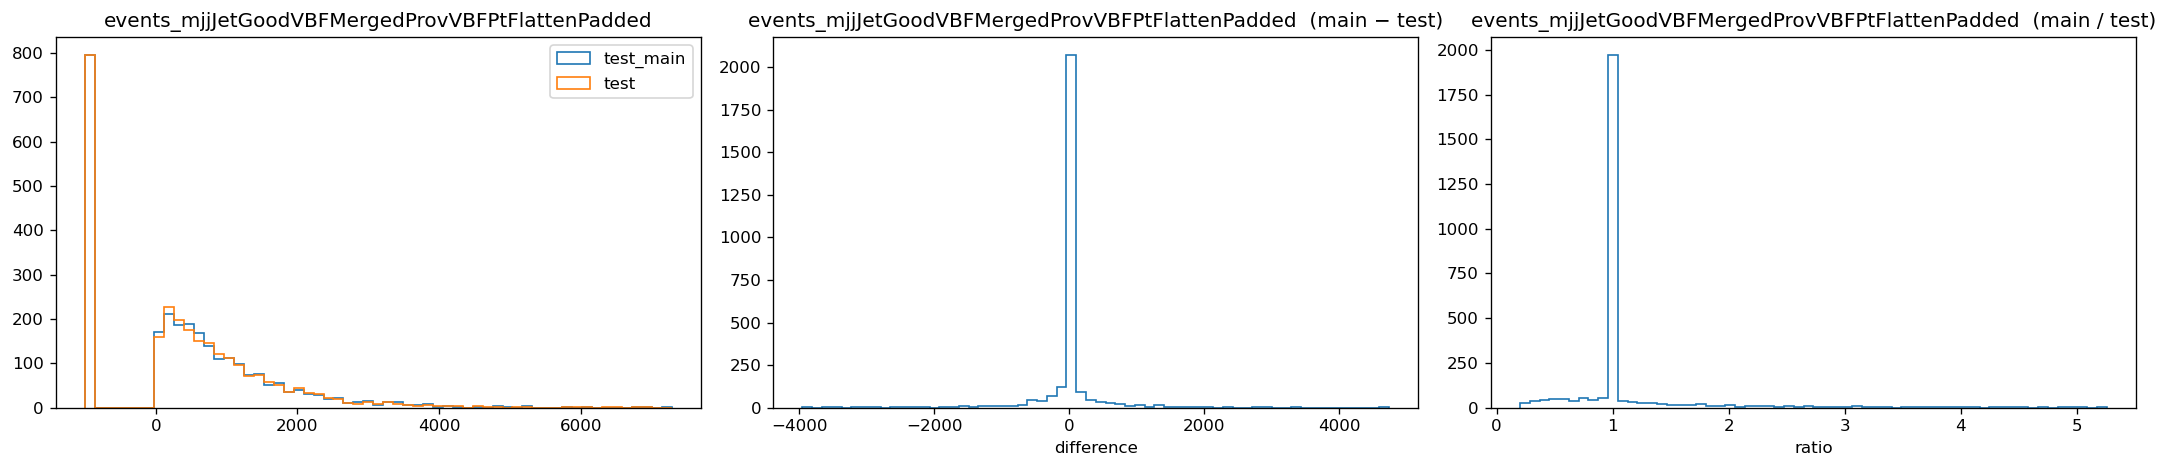

In [19]:
for col, (v1, v2, n_diff) in diffs.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    lo = min(float(v1.min()), float(v2.min()))
    hi = max(float(v1.max()), float(v2.max()))
    bins = np.linspace(lo, hi, 60)

    axes[0].hist(v1, bins=bins, histtype="step", label="test_main")
    axes[0].hist(v2, bins=bins, histtype="step", label="test")
    axes[0].set_title(col)
    axes[0].legend()

    axes[1].hist(v1 - v2, bins=60, histtype="step")
    axes[1].set_title(f"{col}  (main − test)")
    axes[1].set_xlabel("difference")

    ratio = v1 / np.where(v2 != 0, v2, np.nan)
    axes[2].hist(ratio[np.isfinite(ratio)], bins=60, histtype="step")
    axes[2].set_title(f"{col}  (main / test)")
    axes[2].set_xlabel("ratio")

    plt.tight_layout()
    plt.show()

## Inspect a specific column

In [21]:
for col, (v1, v2, n_diff) in diffs.items():
    print(f"\n--- {col}  ({n_diff}/{len(v1)} entries differ) ---")
    idx = np.where(v1 != v2)[0]
    print(f"  {'index':>8s}  {'test_main':>20s}  {'test':>20s}  {'delta':>20s}   {'ratio':>20s}")
    for i in idx[:5]:
        a, b = float(v1[i]), float(v2[i])
        print(f"  {i:>8d}  {a:>20.6g}  {b:>20.6g}  {a-b:>20.6g}   {a/b:>20.6g}")


--- JetTotalSPANetPtFlattenPadded_pt  (6659/24534 entries differ) ---
     index             test_main                  test                 delta                  ratio
      2322               95.5609               64.0926               31.4683                1.49098
      2323               72.2613               48.4656               23.7957                1.49098
      2324               38.9863                26.148               12.8382                1.49098
      2325                81.496               54.6593               26.8367                1.49098
      2326               42.0656               28.2133               13.8522                1.49098

--- JetTotalSPANetPtFlattenPadded_mass  (6659/24534 entries differ) ---
     index             test_main                  test                 delta                  ratio
      2322               15.1463               10.1586                4.9877                1.49098
      2323               12.8186               8.59742  

In [ ]:
col = "events_random_pt_weights"
# col="JetTotalSPANetSeparateProvHiggsVBFPadded_btagPNetB"
v1 = cat_main[col].value
v2 = cat_test[col].value

print(f"{'index':>8s}  {'test_main':>20s}  {'test':>20s}  {'delta':>20s}")
for i in range(len(v1)):
    a, b = float(v1[i]), float(v2[i])
    print(f"{i:>8d}  {a:>20.6g}  {b:>20.6g}  {a-b:>20.6g}")

   index             test_main                  test                 delta
       0               1.51265               1.51265                     0
       1              0.597275              0.597275                     0
       2              0.812907              0.812907                     0
       3               1.65188               1.65188                     0
       4               1.25793               1.25793                     0
       5              0.916213              0.916213                     0
       6              0.470854              0.470854                     0
       7               1.55276               1.55276                     0
       8               1.13706               1.13706                     0
       9              0.844148              0.844148                     0
      10               1.46023               1.46023                     0
      11              0.799455              0.799455                     0
      12              0.4

## Cutflow comparison

In [ ]:
def flat_cutflow(o):
    out = {}
    def _recurse(d, prefix):
        for k, v in d.items():
            key = f"{prefix}/{k}" if prefix else k
            if isinstance(v, dict):
                _recurse(v, key)
            else:
                out[key] = v
    _recurse(o.get("cutflow", {}), "")
    return out

cf_main = flat_cutflow(o_main)
cf_test  = flat_cutflow(o_test)

all_keys = sorted(set(cf_main) | set(cf_test))
print(f"{'key':<70s}  {'test_main':>12s}  {'test':>12s}  {'delta':>12s}")
print("-" * 110)
for k in all_keys:
    v1 = cf_main.get(k)
    v2 = cf_test.get(k)
    delta = (v1 - v2) if (v1 is not None and v2 is not None) else "N/A"
    print(f"{k:<70s}  {str(v1):>12s}  {str(v2):>12s}  {str(delta):>12s}")

key                                                                        test_main          test         delta
--------------------------------------------------------------------------------------------------------------
4b_region/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4/nominal          2726          2726             0
hh4b_vbf_best_candidates_6_jets_nokincut_region/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4/nominal          None          2027           N/A
hh4b_vbf_best_candidates_6_jets_region/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4/nominal          None          1347           N/A
initial/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE                        78196         78196             0
presel/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE/nominal                 12128         12126             2
skim/VBFHHto4B_CV-1p74_C2V-1p37_C3-14p4__2022_postEE  